In [8]:
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import pandas as pd
import hashlib
import glob
import os

from src.ask import sigAssistant
from src.dbkg import consolidateBits
from src.impt import integrateReview 
brain = sigAssistant(pathDefinitions="doc/definitions/content.md", pathCache="./cache/")

In [2]:
from tqdm import tqdm
tqdm.pandas()

# Read

In [5]:
lsxlsx = glob.glob("doc/WIP/**/*.xlsx")
lsxlsx

['doc/WIP/BXL/OUT_Reviewed_-Brussels_Vision.xlsx',
 'doc/WIP/BXL/OUT_Reviewed_-Brussels_Activities.xlsx',
 'doc/WIP/MAD/MADRID_Vision.xlsx',
 'doc/WIP/MAD/MADRID_Activities.xlsx',
 'doc/WIP/AAR/OUT_Reviewed_-Aarhus_Activities.xlsx',
 'doc/WIP/AAR/OUT_Reviewed_-Aarhus_Vision.xlsx',
 'doc/WIP/PRT/D_D7.12-Porto_Reviewed_Activities_18.10.2024.xlsx',
 'doc/WIP/PRT/D_D7.12-Porto_Reviewed_Vision.xlsx',
 'doc/WIP/PRG/OUT_Reviewed_-Prague_Vision.xlsx',
 'doc/WIP/PRG/OUT_Reviewed_-Prague_Activities.xlsx']

In [12]:
MDACT = [ "45c5467e9e73", 
 "80daa3aae2f2", 
 "53c83ec1f442", 
 "9db9acb35f60", 
"60a6999f4ee9", 
"ee55f32aa6ac", 
 "17639e745681", 
 "a8f5da2ebc8b" , 
 "9716f08eabf7" , 
 "ce2251abba2a" ]

In [14]:
for x in lsxlsx:
    if x == 'doc/WIP/MAD/MADRID_Activities.xlsx':
        integrateReview(x,lst=MDACT)
    else:
        integrateReview(x)

Processing reviewed data from doc/WIP/BXL/OUT_Reviewed_-Brussels_Vision.xlsx 20 Vision
Processing reviewed data from doc/WIP/BXL/OUT_Reviewed_-Brussels_Activities.xlsx 20 Activities
Processing reviewed data from doc/WIP/BXL/OUT_Reviewed_-Brussels_Activities.xlsx 20 Activities
Processing reviewed data from doc/WIP/BXL/OUT_Reviewed_-Brussels_Activities.xlsx 20 Activities
Processing reviewed data from doc/WIP/BXL/OUT_Reviewed_-Brussels_Activities.xlsx 20 Activities
Processing reviewed data from doc/WIP/BXL/OUT_Reviewed_-Brussels_Activities.xlsx 20 Activities
Processing reviewed data from doc/WIP/BXL/OUT_Reviewed_-Brussels_Activities.xlsx 20 Activities
Processing reviewed data from doc/WIP/MAD/MADRID_Vision.xlsx 16 Vision
Processing reviewed data from doc/WIP/MAD/MADRID_Vision.xlsx 15 Vision
Processing reviewed data from doc/WIP/MAD/MADRID_Vision.xlsx 16 Vision
Processing reviewed data from doc/WIP/MAD/MADRID_Vision.xlsx 20 Vision
Processing reviewed data from doc/WIP/MAD/MADRID_Vision.xls

In [15]:
df = consolidateBits(PATH="./data/xls/")
print(len(df),"reviews")

919 reviews


In [23]:
import src.img as iImg
from src.reportmgr import createExcel

/home/kelu/projets/probono37k/src/img.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/probono37k/src/img.py:152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels,fontproperties=fontprop, fontsize=24, weight='bold')
/home/kelu/projets/probono37k/venv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/home/kelu/projets/probono37k/src/reportmgr.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

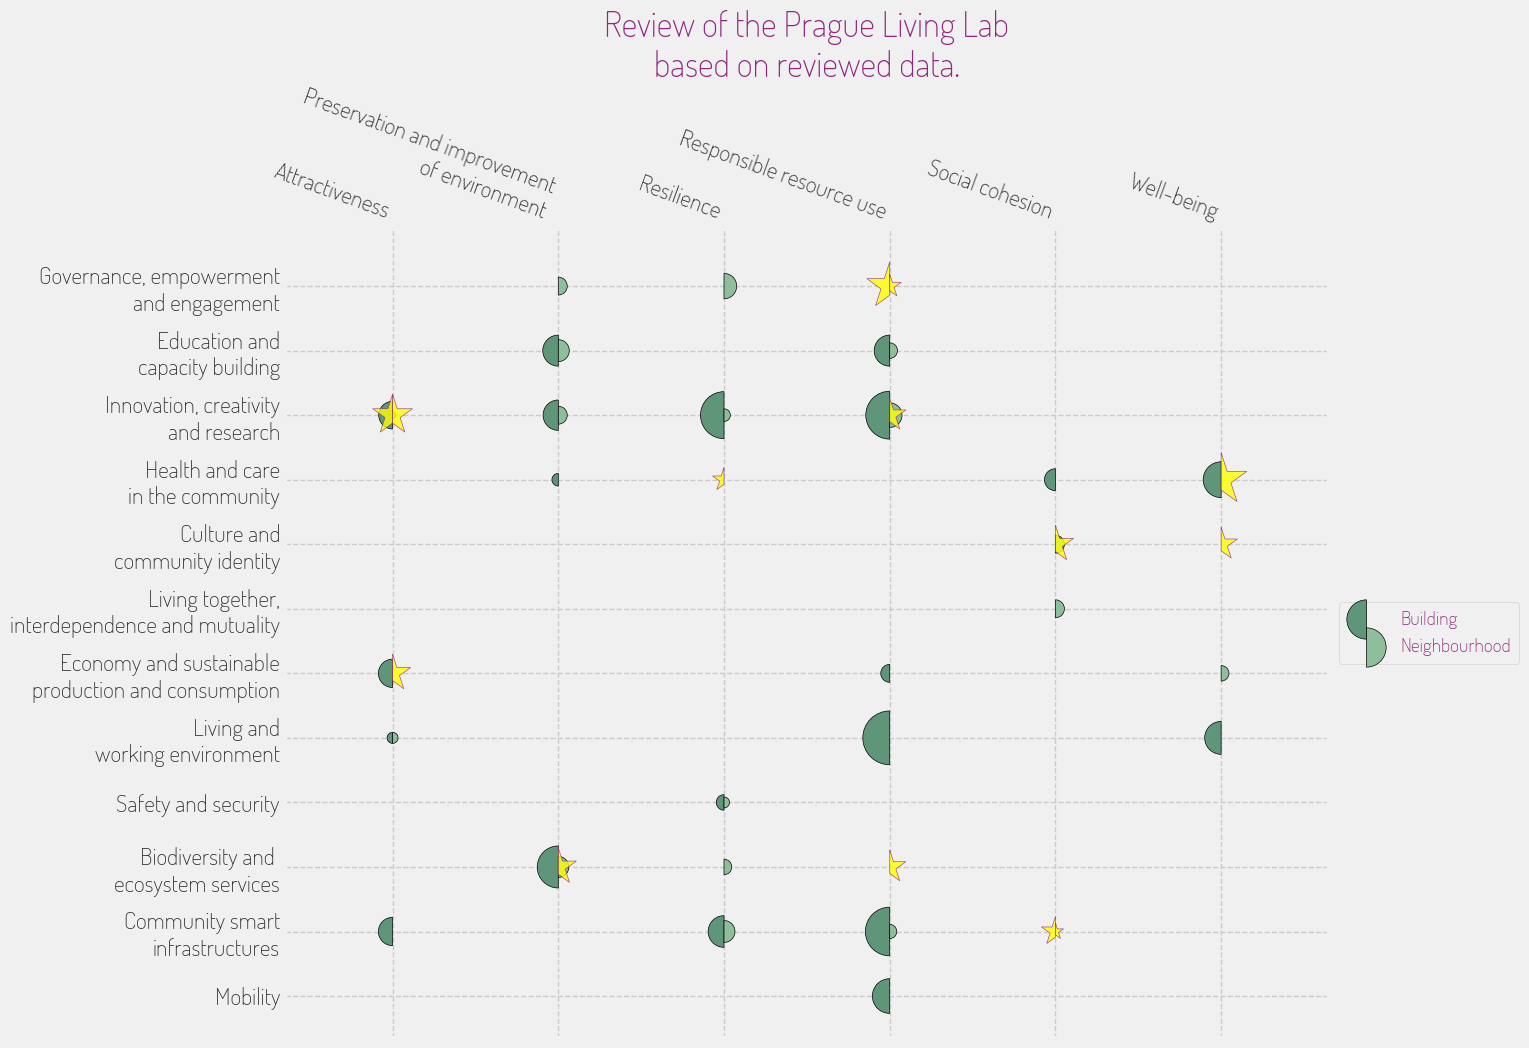

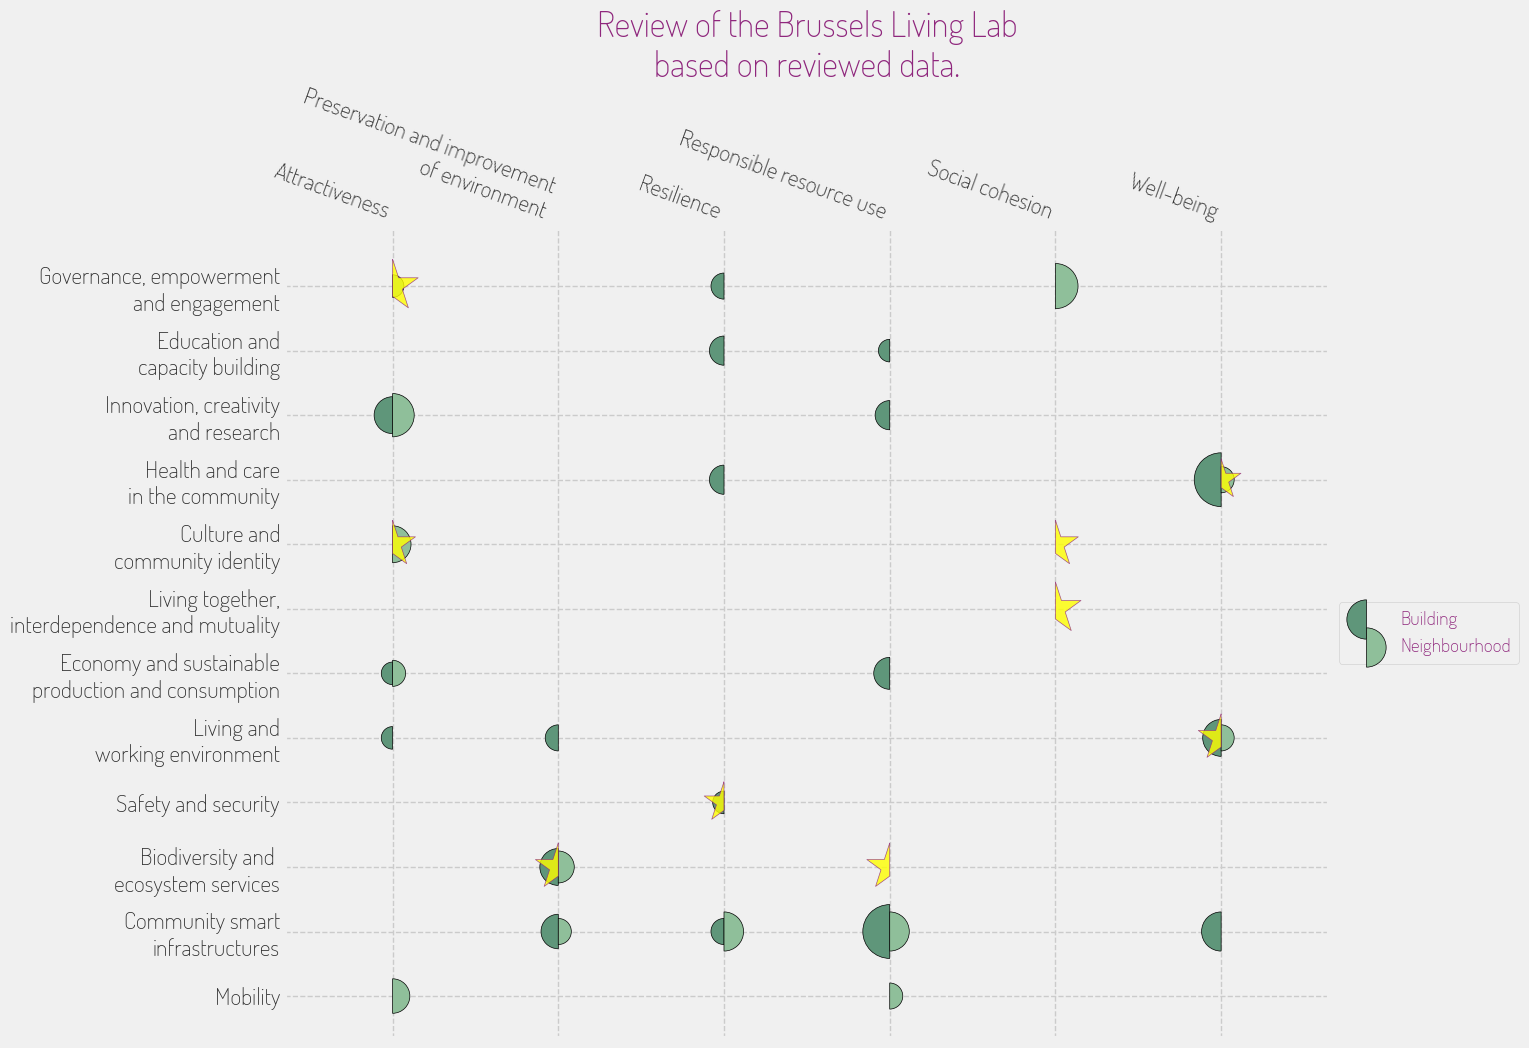

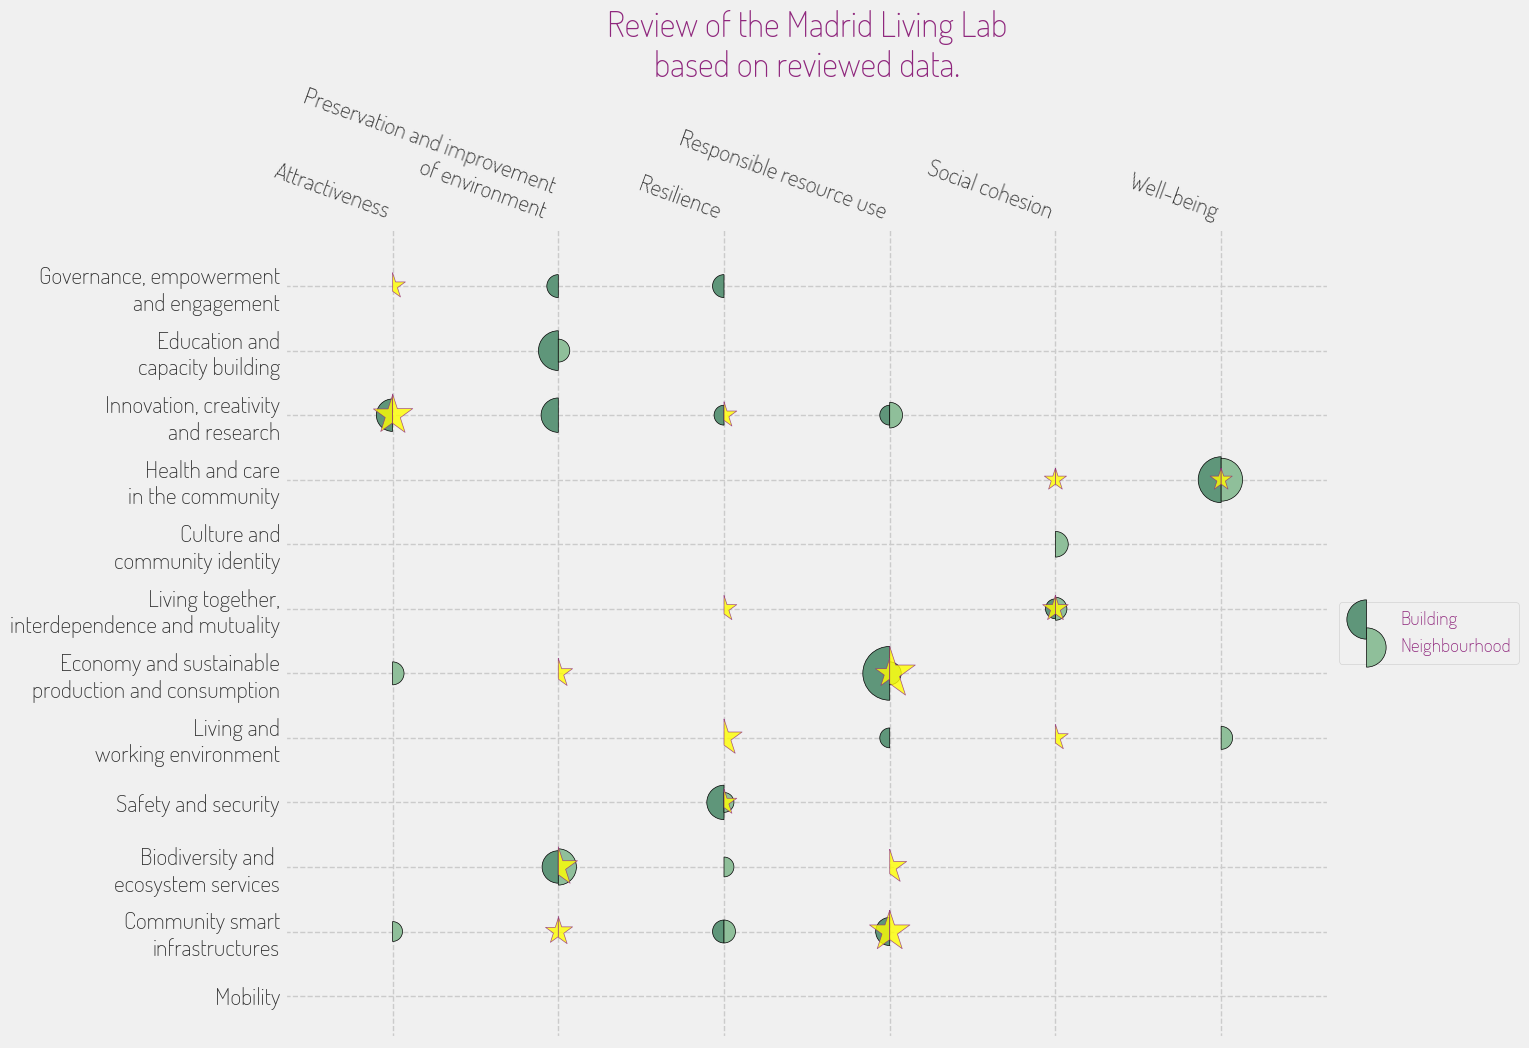

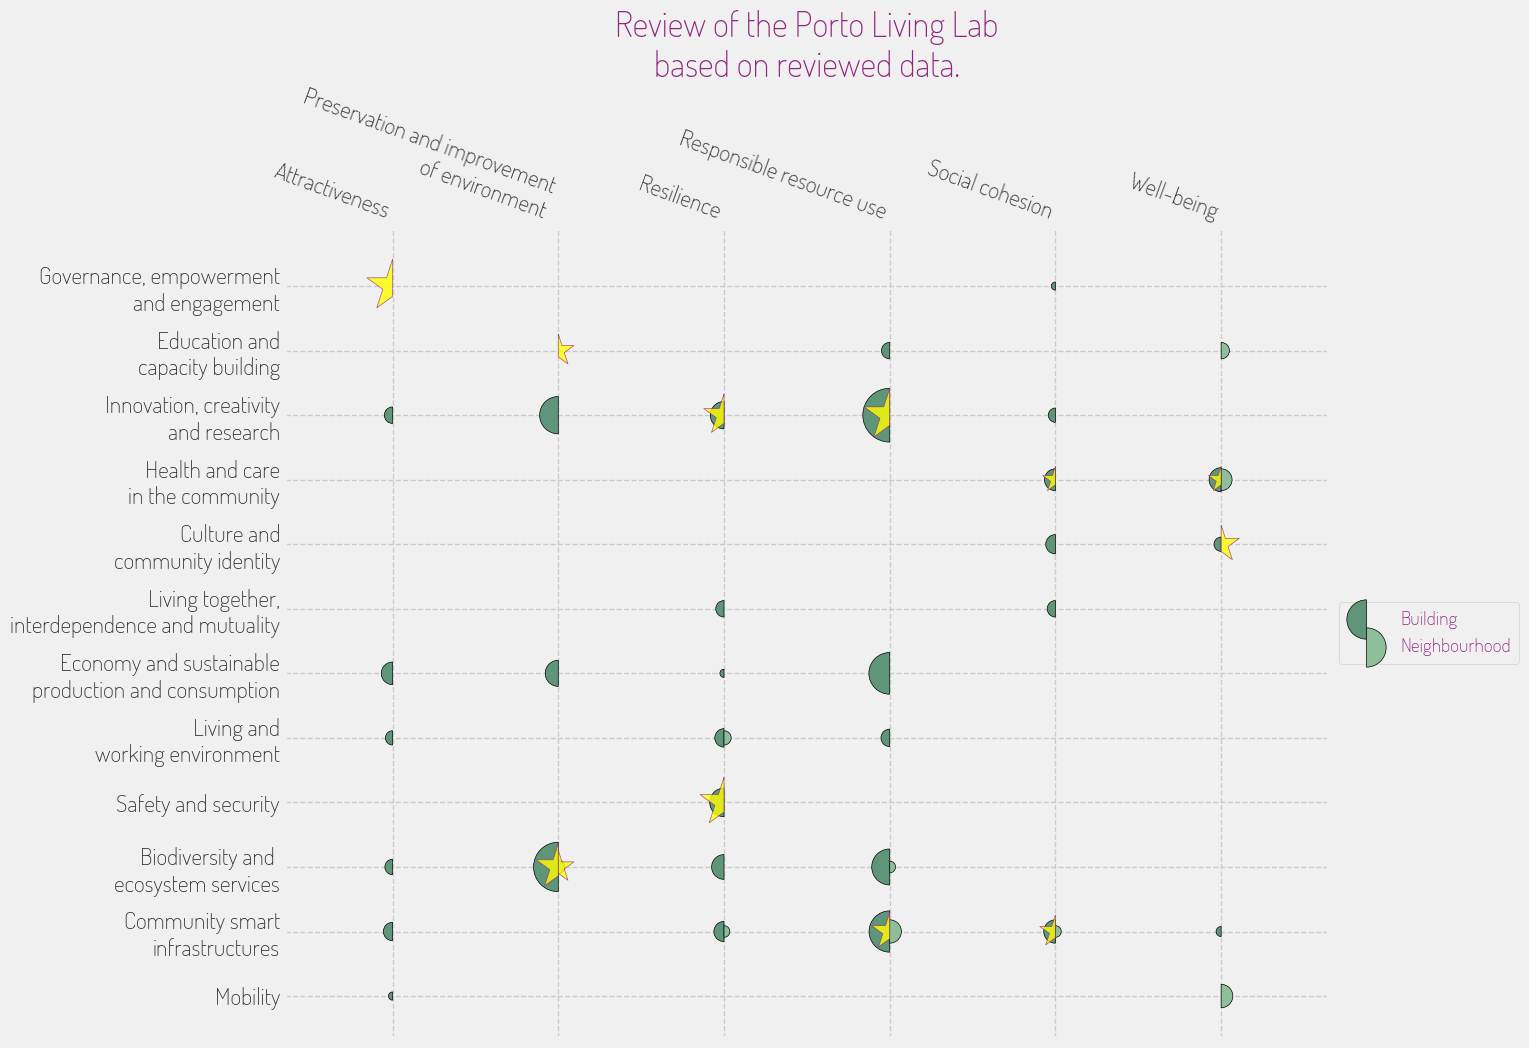

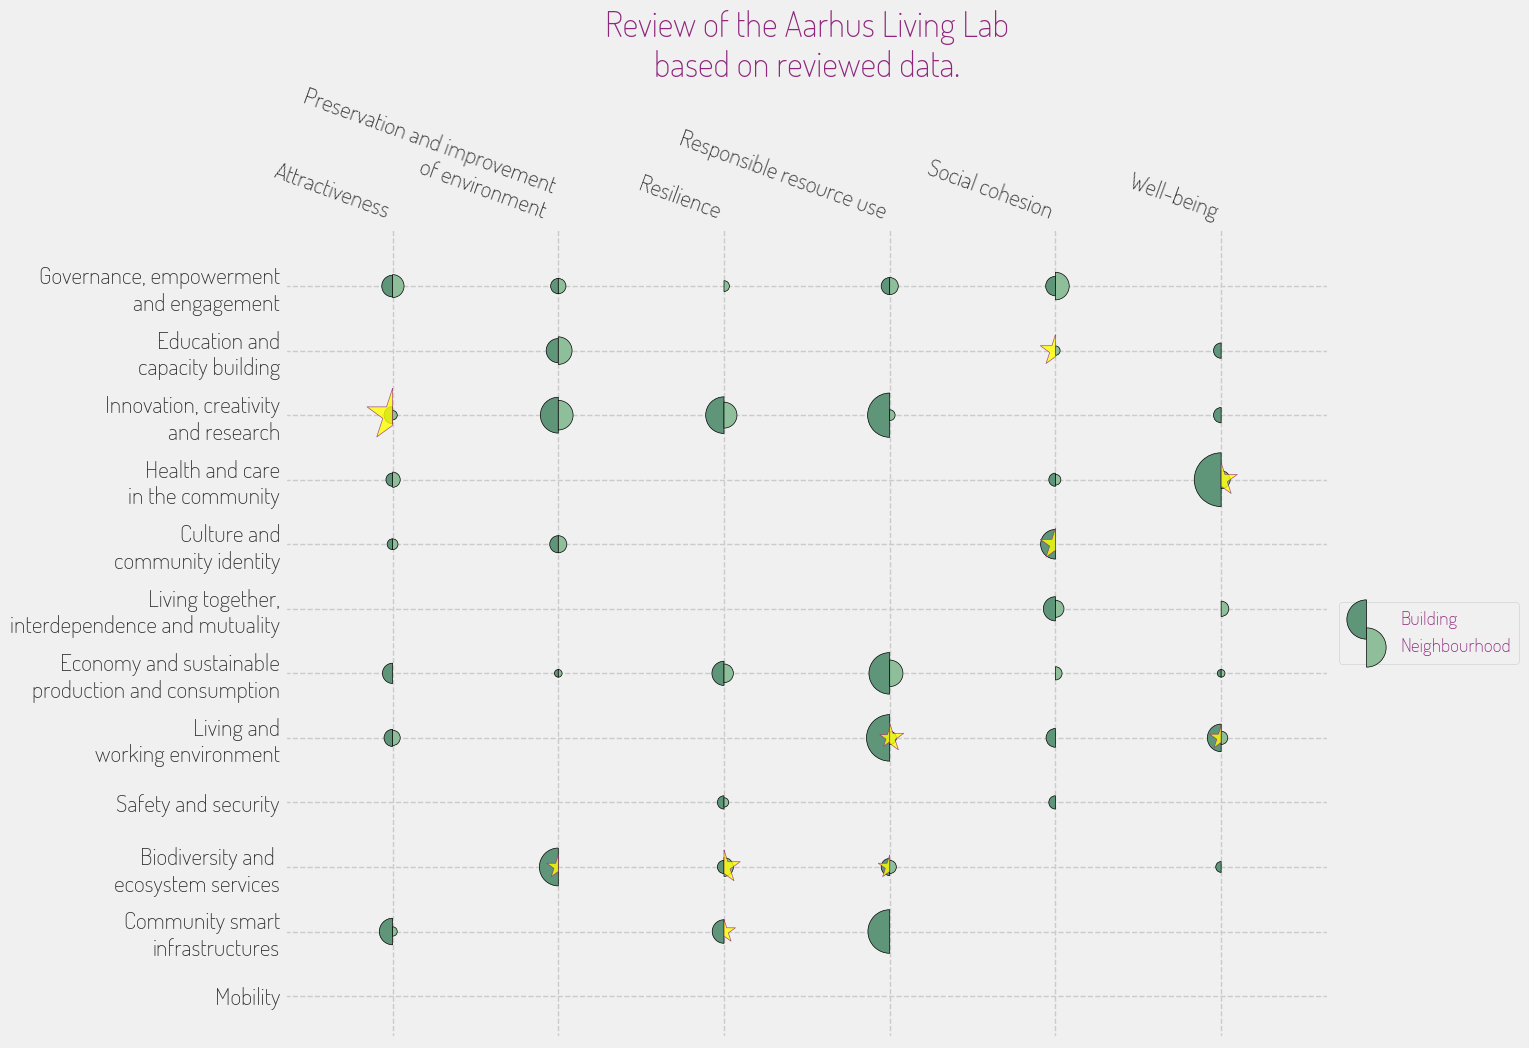

In [25]:
for LL in df.Place.unique():
    D = df[df.Place == LL]

    dfRef = D[D.Type == "Vision"]
    dfUC  = D[D.Type == "Activities"]
    plt, ax = iImg.createImg(dfUC,dfRef,title="Review of the "+LL+" Living Lab\nbased on reviewed data.")

    createExcel(dfRef,"doc/outputs/iso37101_Vision_"+LL+".xlsx","Consolidated review of the "+LL+" LL vision.","Across WP",LL)
    createExcel(dfUC,"doc/outputs/iso37101_Activities_"+LL+".xlsx","Consolidated review of the "+LL+" LL activities.","Across WP",LL)
    plt.savefig("doc/outputs/iso37101_map_"+LL+".png", bbox_inches='tight')
    plt.savefig("doc/outputs/iso37101_map_"+LL+".svg", bbox_inches='tight')

In [19]:
for LL in df.Place.unique():
    D = df[df.Place == LL]

In [21]:
D.Type.unique()

array(['Activities', 'Vision'], dtype=object)